# 5058 Project 1
## Time Series Analysis with Financial Data

- Name: LAN, Tianwei  
- Student ID: 21230969  
- Email: tlanaa@connect.ust.hk

## 1. Data Preprocessing

This section uses Apple Inc. (AAPL) and Microsoft Inc. (MSFT) as research subjects. Historical daily closing price data was downloaded from Yahoo Finance's `yfinance` interface. To meet the requirement of more than 4000 trading days, the research period was set to all trading days from 2008 to 2023.

The aligned daily closing price sequences are denoted as $S_1(t)$ and $S_2(t)$, respectively. The daily logarithmic return is defined as:

$$
X_i(t) = \ln\left(\frac{S_i(t)}{S_i(t-1)}\right), \quad i = 1, 2.
$$

After calculating the returns, the sequences are reduced in dimensionality by subtracting the sample mean to ensure that the mean of each updated return sequence is zero.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Acquisition
# Selecting AAPL and MSFT as they have more than 15 years of data
tickers = ['AAPL', 'MSFT']
start_date = "2008-01-01"
end_date = "2024-01-01"

print(f"Downloading data for {tickers}...")
data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Check if data meets the > 4000 days requirement
print(f"Data points available: {len(data)}")
if len(data) < 4000:
    print("Warning: Data length is less than 4000 days.")

[*********************100%***********************]  2 of 2 completed

Data points available: 4027


In [3]:
# 2. Calculation
# S(t) are the closing prices
S1 = data[tickers[0]]
S2 = data[tickers[1]]

# Calculate X(t) = ln(S(t) / S(t-1))
X1 = np.log(S1 / S1.shift(1)).dropna()
X2 = np.log(S2 / S2.shift(1)).dropna()

# Zero-Mean Centering
X1_centered = X1 - X1.mean()
X2_centered = X2 - X2.mean()

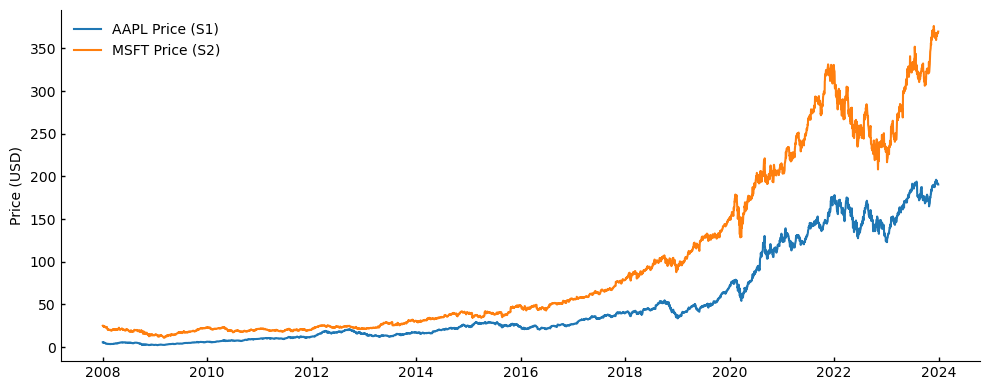

In [12]:
# Plotting Stock Prices S(t)
# Title: Daily Closing Prices (S(t))
plt.figure(figsize=(10,4))
plt.plot(S1.index, S1, label=f'{tickers[0]} Price (S1)')
plt.plot(S2.index, S2, label=f'{tickers[1]} Price (S2)')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left', frameon=False, fontsize=10)
plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.tick_params(direction='in', length=3, width=1)

plt.tight_layout()
plt.savefig('1_stock_prices.eps', format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


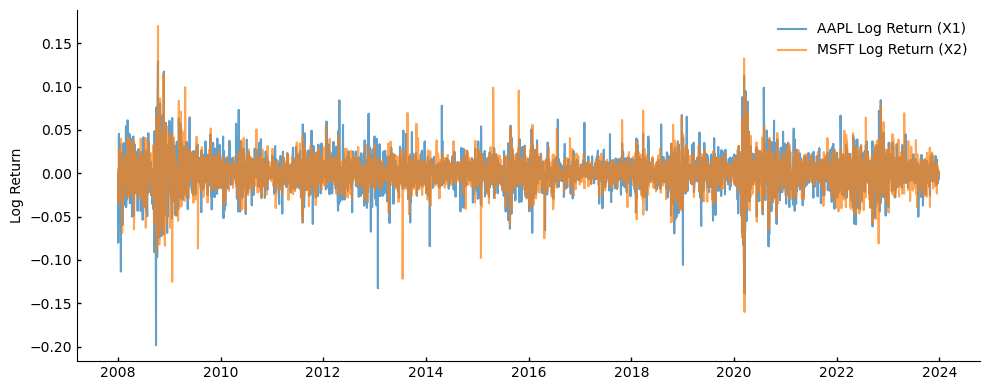

In [13]:
# Plotting Daily Returns X(t)
# Title: Zero-Mean Daily Log Returns (X(t))
plt.figure(figsize=(10,4))
plt.plot(X1_centered.index, X1_centered, label=f'{tickers[0]} Log Return (X1)', alpha=0.7)
plt.plot(X2_centered.index, X2_centered, label=f'{tickers[1]} Log Return (X2)', alpha=0.7)
plt.ylabel('Log Return')
plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.tick_params(direction='in', length=3, width=1)

plt.tight_layout()
plt.savefig('2_log_returns.eps', format='eps', bbox_inches='tight')
plt.show()

## 2. Stationarity and Autocorrelation

### 2.1 Stationarity Testing
Perform an ADF Test on $X$ to judge its stationarity. 

In [6]:
# ADF Test for Stationarity 
from statsmodels.tsa.stattools import adfuller

def adf_test_df(series_list, titles):
    results = {}
    for series, title in zip(series_list, titles):
        res = adfuller(series.dropna(), autolag='AIC')
        stats = {
            'ADF Statistic': res[0],
            'p-value': res[1],
            '# Lags': int(res[2]),
            '# Obs': int(res[3]),
            'Critical 1%': res[4]['1%'],
            'Critical 5%': res[4]['5%'],
            'Critical 10%': res[4]['10%'],
            'Stationary': "Yes" if res[1] <= 0.05 else "No" # 添加平稳性结论
        }
        results[title] = stats
    
    df = pd.DataFrame(results)
    return df.map(lambda x: f"{x:.2f}" if isinstance(x, (float, int)) else x)

df_results = adf_test_df([X1_centered, X2_centered], [tickers[0], tickers[1]])
df_results

,AAPL,MSFT
ADF Statistic,-15.12,-22.81
p-value,0.00,0.00
# Lags,15.00,8.00
# Obs,4010.00,4017.00
Critical 1%,-3.43,-3.43
Critical 5%,-2.86,-2.86
Critical 10%,-2.57,-2.57
Stationary,Yes,Yes


### 2.2 Linear Autocorrelation and ARMA Identification
Do ACF and PACF Analysis, then select the best ARMA model

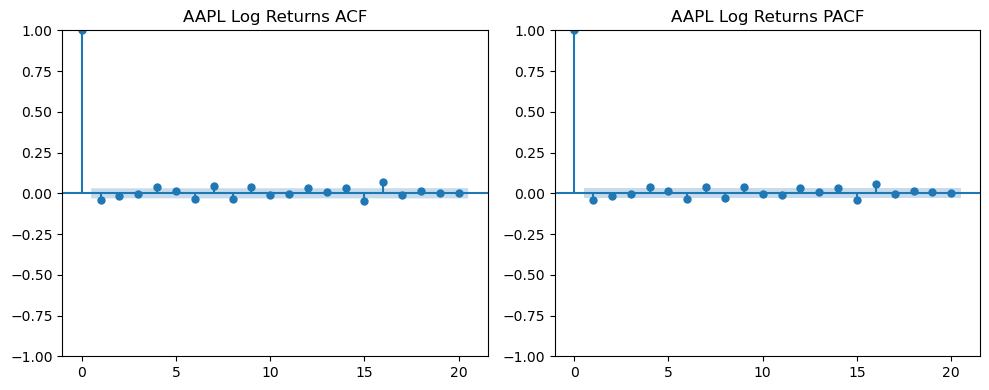

In [16]:
# ACF and PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_acf(X1_centered, lags=20, ax=plt.gca(), title=f'{tickers[0]} Log Returns ACF')
plt.subplot(1,2,2)
plot_pacf(X1_centered, lags=20, ax=plt.gca(), title=f'{tickers[0]} Log Returns PACF')
plt.tight_layout()
plt.savefig('3_acf_pacf_X1.png', format='png', bbox_inches='tight')
plt.show()

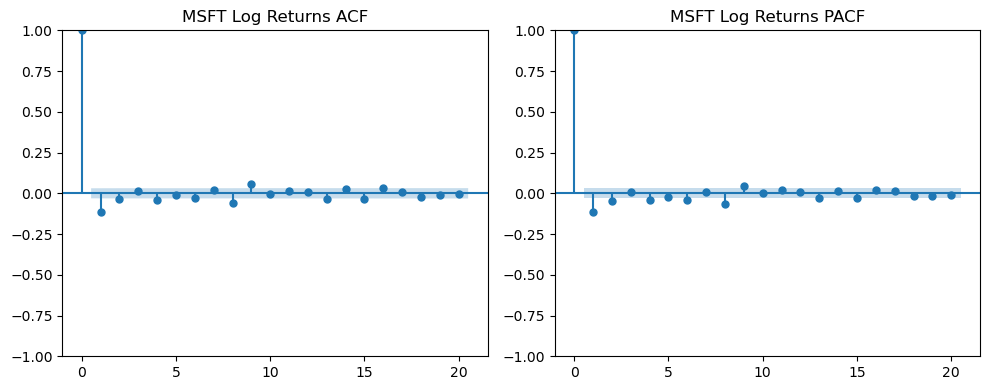

In [17]:
# ACF and PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_acf(X2_centered, lags=20, ax=plt.gca(), title=f'{tickers[1]} Log Returns ACF')
plt.subplot(1,2,2)
plot_pacf(X2_centered, lags=20, ax=plt.gca(), title=f'{tickers[1]} Log Returns PACF')
plt.tight_layout()
plt.savefig('4_acf_pacf_X2.png', format='png', bbox_inches='tight')
plt.show()

For both stocks, since most orders of ACF/PACF are not significant, the return series conforms to the weak-form efficient market hypothesis. It is recommended to choose ARMA(0,0) or a very low-order model.

Combined with the previous ADF test, this indicates that the stock price fluctuations are relatively smooth, with no significant long-term upward or downward trend; the daily price movements are almost random.

### 2.3 Non-linear Autocorrelation Analysis
Plot the ACF of $|X|$ (absolute returns) and compare the trends of the two autocorrelations. 

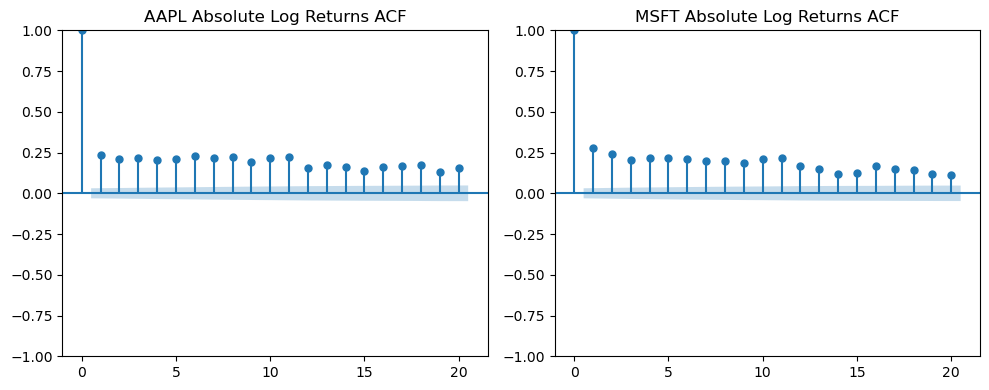

In [18]:
# plot the ACF of absolute returns |X(t)| to check for volatility clustering
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_acf(np.abs(X1_centered), lags=20, ax=plt.gca(), title=f'{tickers[0]} Absolute Log Returns ACF')
plt.subplot(1,2,2)
plot_acf(np.abs(X2_centered), lags=20, ax=plt.gca(), title=f'{tickers[1]} Absolute Log Returns ACF')
plt.tight_layout()
plt.savefig('5_acf_abs_returns.png', format='png', bbox_inches='tight')
plt.show()

This phenomenon indicates that the return series itself has almost no linear correlation (i.e., the direction is unpredictable, close to an efficient market), but its volatility exhibits a significant nonlinear correlation, reflecting the typical **volatility clustering** characteristic in financial markets.

## 3. Fractal Behaviour of Time Series 

### 3.1 Hurst Exponent
This section calculates the Hurst exponent of the sequence using R/S analysis and plots a scatter plot of $\log(n)$ versus $\log(R/S)$.

AAPL Hurst Exponent: 0.4801
MSFT Hurst Exponent: 0.4821


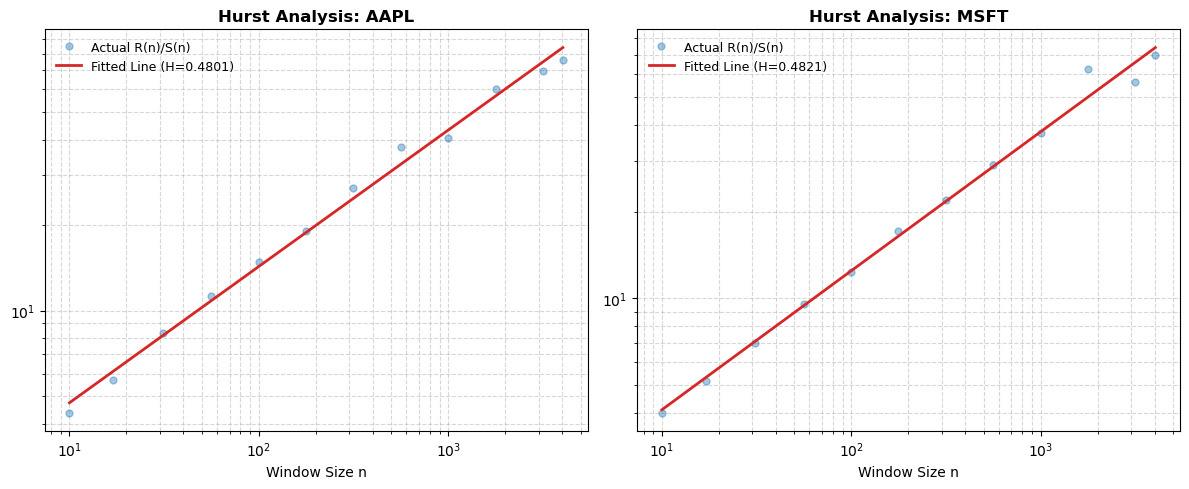

In [ ]:
from hurst import compute_Hc

def analyze_hurst_combined(series1, series2, tickers):
    # Setup the figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    data_list = [series1, series2]
    
    for i, ax in enumerate(axes):
        series = np.asarray(data_list[i]).flatten()
        name = tickers[i]
        
        # 1. Compute Hurst Exponent
        H, c, data = compute_Hc(series, kind='change', simplified=True)
        print(f"{name} Hurst Exponent: {H:.4f}")
        
        # 2. Plotting on the respective subplot
        # Actual R/S data points
        ax.plot(data[0], data[1], 'o', c='#1f77b4', alpha=0.4, markersize=5, label='Actual R(n)/S(n)')
        
        # Fitted Line: R(n) ~ c * n^H
        ax.plot(data[0], c * data[0]**H, color='#d62728', lw=2, label=f'Fitted Line (H={H:.4f})')
        
        # Formatting
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Window Size n', fontsize=10)
        # ax.set_ylabel('Rescaled Range R(n)/S(n)', fontsize=10)
        ax.set_title(f'Hurst Analysis: {name}', fontsize=12, fontweight='bold')
        ax.legend(loc='upper left', frameon=False, fontsize=9)
        ax.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    # Save as PDF or PNG for high quality in Overleaf/LaTeX
    plt.savefig('6_hurst_comparison_combined.png', format='png', bbox_inches='tight')
    plt.show()

# Execution
analyze_hurst_combined(X1_centered, X2_centered, tickers)

The log returns of AAPL and MSFT are predominantly stochastic and memoryless, behaving as nearly perfect Brownian motion with no significant long-term trending or mean-reverting bias.

### 3.2 Detrended Fluctuation Analysis (DFA)

DFA is an alternative method to Hurst Exponent for detecting long-range correlations in non-stationary time series. It is often considered more robust because it removes local trends that can lead to a false detection of long-range memory.

The scaling exponent α is theoretically equivalent to the Hurst exponent (H) for stationary noise-like series (such as log returns).

AAPL DFA Alpha: 0.5515
MSFT DFA Alpha: 0.4626


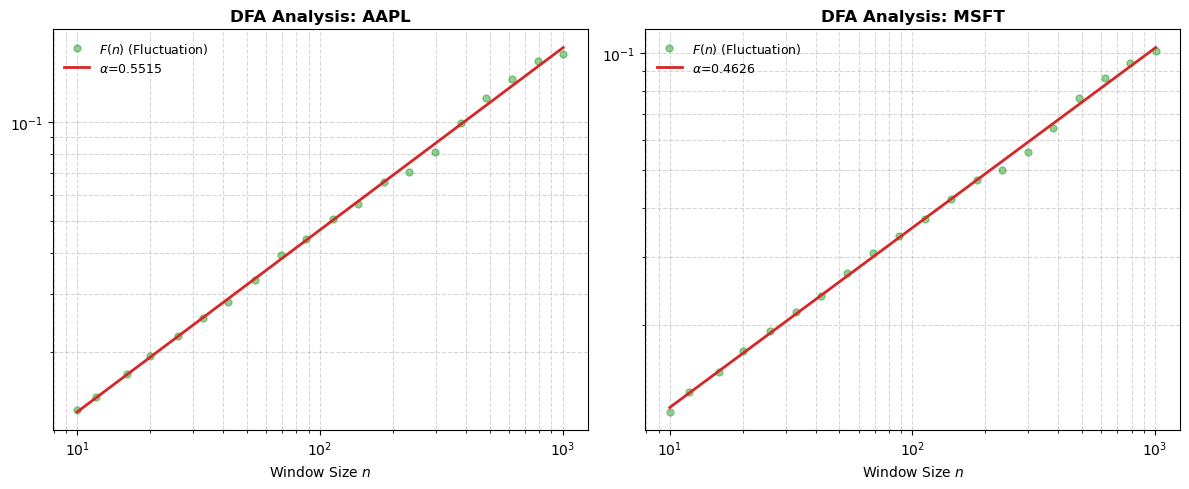

In [ ]:
from scipy.stats import linregress

def analyze_dfa_combined(series1, series2, tickers):
    # Setup the figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    data_list = [series1, series2]
    
    for i, ax in enumerate(axes):
        # Ensure we are working with a 1D numpy array
        s_val = np.asarray(data_list[i]).flatten()
        name = tickers[i]
        
        # 1. Integrate the series (Cumulative Sum)
        y = np.cumsum(s_val - np.mean(s_val))
        
        # 2. Define window sizes (n) - following log scale
        n_values = np.unique(np.logspace(1, np.log10(len(y)/4), num=20).astype(int))
        fluctuations = []
        
        for n in n_values:
            num_segments = len(y) // n
            # Reshape into windows
            segments = y[:num_segments * n].reshape((num_segments, n))
            
            x_axis = np.arange(n)
            segment_rms = []
            for seg in segments:
                # Local detrending (linear fit)
                slope, intercept, _, _, _ = linregress(x_axis, seg)
                trend = slope * x_axis + intercept
                rms = np.sqrt(np.mean((seg - trend)**2))
                segment_rms.append(rms)
            
            fluctuations.append(np.mean(segment_rms))
        
        # 3. Calculate Alpha (Scaling Exponent) via log-log regression
        log_n = np.log(n_values)
        log_f = np.log(fluctuations)
        alpha, intercept, _, _, _ = linregress(log_n, log_f)
        
        print(f"{name} DFA Alpha: {alpha:.4f}")
        
        # 4. Visualization on the respective subplot
        ax.plot(n_values, fluctuations, 'o', c='#2ca02c', alpha=0.5, markersize=5, label='$F(n)$ (Fluctuation)')
        ax.plot(n_values, np.exp(intercept) * n_values**alpha, color='#d62728', lw=2, label=f'$\\alpha$={alpha:.4f}')
        
        # Formatting for academic look
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Window Size $n$', fontsize=10)
        # ax.set_ylabel('Fluctuation $F(n)$', fontsize=10)
        ax.set_title(f'DFA Analysis: {name}', fontsize=12, fontweight='bold')
        ax.legend(loc='upper left', frameon=False, fontsize=9)
        ax.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    # Save as PDF for high-quality LaTeX integration
    plt.savefig('7_dfa_comparison_combined.png', format='png', bbox_inches='tight')
    plt.show()

# Execution
analyze_dfa_combined(X1_centered, X2_centered, tickers)

### 3.3 Multifractality

Previous methods like the Hurst index and DFA actually assumed that the sequence was monofractal, meaning that self-similarity was constant across all scales and volatility levels. However, financial data (such as stock prices) typically exhibits multifractal characteristics, meaning that the scaling patterns of large and small fluctuations differ.

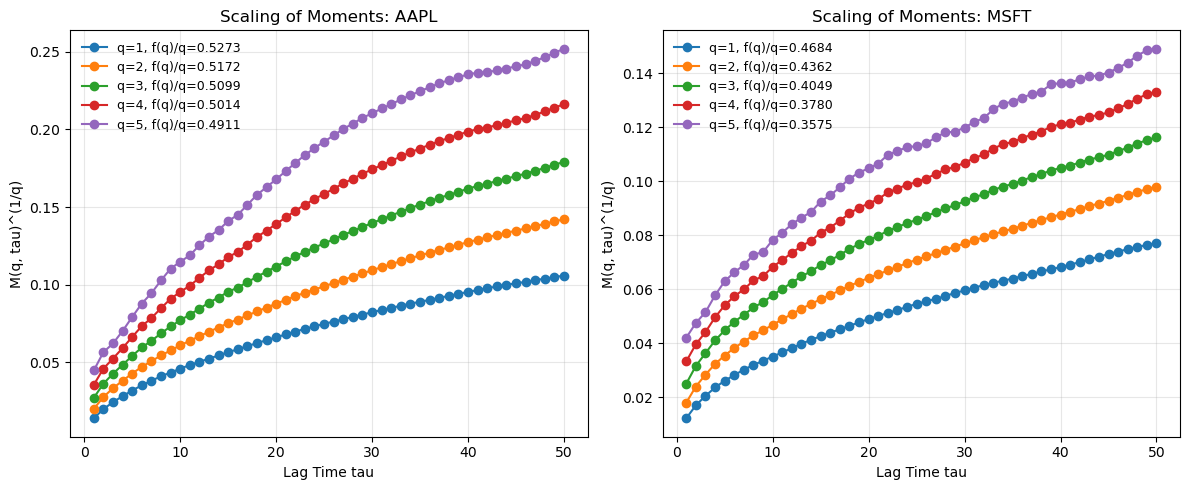

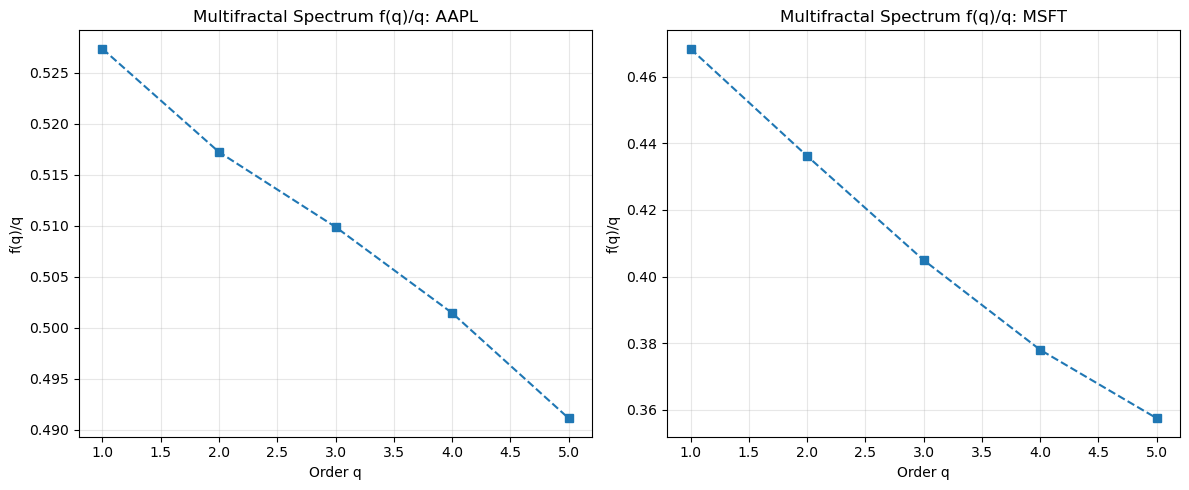

In [ ]:
def analyze_multifractal_combined(series1, series2, tickers):
    data_list = [series1, series2]
    taus = np.arange(1, 51)
    qs = [1, 2, 3, 4, 5]
    
    # Scaling of Moments
    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))
    all_f_q = []
    
    for i, ax in enumerate(axes1):
        Y = np.cumsum(np.asarray(data_list[i]).flatten())
        name = tickers[i]
        f_q_list = []
        
        for q in qs:
            m_q_tau = []
            for tau in taus:
                diffs = np.abs(Y[tau:] - Y[:-tau])
                m_q_tau.append(np.mean(diffs**q))
            
            # 计算线性回归
            log_tau = np.log(taus)
            log_m = np.log(m_q_tau)
            f_q, _, _, _, _ = linregress(log_tau, log_m)
            f_q_list.append(f_q)
            
            # 绘图：保持原有参数风格
            ax.plot(taus, np.array(m_q_tau)**(1/q), 'o-', label=f'q={q}, f(q)/q={f_q/q:.4f}')
        
        all_f_q.append(f_q_list)
        ax.set_xlabel('Lag Time tau')
        ax.set_ylabel('M(q, tau)^(1/q)')
        ax.set_title(f'Scaling of Moments: {name}')
        ax.legend(loc='upper left', frameon=False, fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('8_scaling_moments_combined.png', format='png', bbox_inches='tight')
    plt.show()

    # f(q)/q Spectrum
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    
    for i, ax in enumerate(axes2):
        name = tickers[i]
        f_qs = np.array(all_f_q[i])
        
        ax.plot(qs, f_qs/qs, 's--')
        ax.set_xlabel('Order q')
        ax.set_ylabel('f(q)/q')
        ax.set_title(f'Multifractal Spectrum f(q)/q: {name}')
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.savefig('9_multifractal_spectrum_combined.png', format='png', bbox_inches='tight')
    plt.show()

# 执行
analyze_multifractal_combined(X1_centered, X2_centered, tickers)

Asset $S$ (and return $X$) are multifractal, and experimental results show that both $\alpha(q)$ and $f(q)/q$ decrease as $q$ increases (AAPL and MSFT). This indicates that large fluctuations ($q > 0$) and small fluctuations ($q < 0$) follow different scaling logics, which is a typical characteristic of multifractal systems.

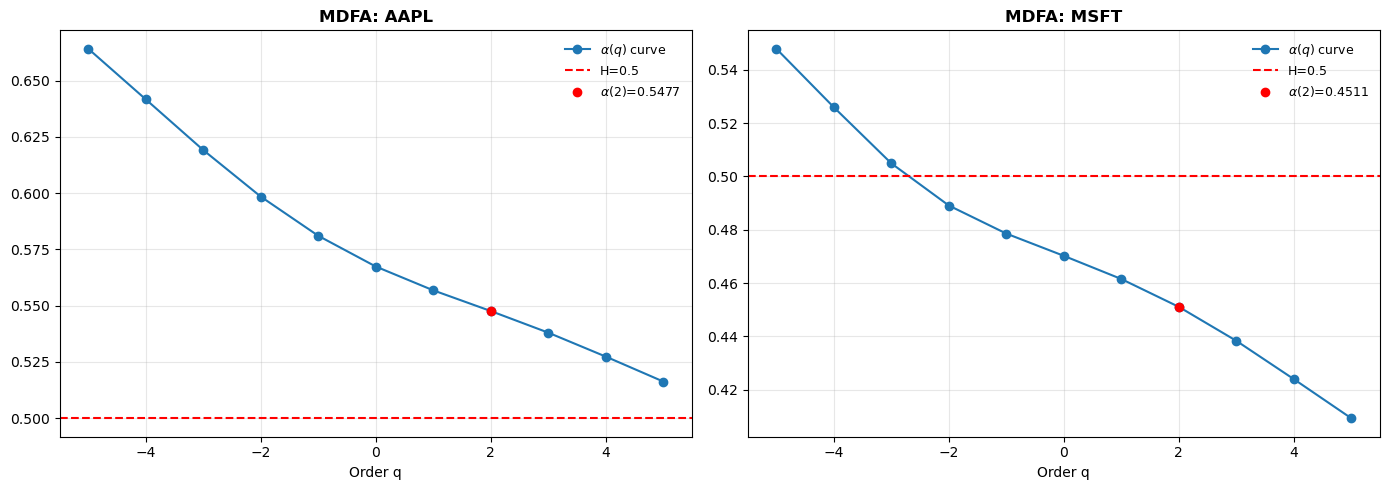

In [37]:
def analyze_mfdfa_combined(series1, series2, tickers):
    # Setup the figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    data_list = [series1, series2]
    
    # Define window sizes and q orders
    qs = np.linspace(-5, 5, 11)
    
    for i, ax in enumerate(axes):
        # Ensure working with a 1D numpy array
        s_val = np.asarray(data_list[i]).flatten()
        name = tickers[i]
        
        # 1. Integrate the series
        y = np.cumsum(s_val - np.mean(s_val))
        n_values = np.unique(np.logspace(1, np.log10(len(y)/4), num=15).astype(int))
        
        alpha_q = []
        for q in qs:
            # Handle q=0 by taking the limit
            curr_q = q if abs(q) > 1e-10 else 1e-10
                
            fluctuations = []
            for n in n_values:
                num_segments = len(y) // n
                segments = y[:num_segments * n].reshape((num_segments, n))
                x_axis = np.arange(n)
                
                segment_vars = []
                for seg in segments:
                    slope, intercept, _, _, _ = linregress(x_axis, seg)
                    # Calculate RMS squared
                    rms_sq = np.mean((seg - (slope * x_axis + intercept))**2)
                    segment_vars.append(rms_sq)
                
                # Generalized fluctuation function F_q(n)
                f_q_n = (np.mean(np.array(segment_vars)**(curr_q/2)))**(1/curr_q)
                fluctuations.append(f_q_n)
                
            # 3. Calculate alpha(q) via log-log slope
            slope, _, _, _, _ = linregress(np.log(n_values), np.log(fluctuations))
            alpha_q.append(slope)

        # 4. Plotting: Maintain original style
        ax.plot(qs, alpha_q, 'o-', label=r'$\alpha(q)$ curve')
        ax.axhline(y=0.5, color='r', linestyle='--', label='H=0.5')
        
        # Identify alpha(2) - which corresponds to the standard DFA exponent
        idx_q2 = np.argmin(np.abs(qs - 2))
        ax.plot(qs[idx_q2], alpha_q[idx_q2], 'ro', label=f'$\\alpha(2)$={alpha_q[idx_q2]:.4f}')
        
        ax.set_xlabel('Order q', fontsize=10)
        # ax.set_ylabel('Generalized Hurst Exponent $\\alpha(q)$', fontsize=10)
        ax.set_title(f'MDFA: {name}', fontsize=12, fontweight='bold')
        ax.legend(loc='best', frameon=False, fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    # Save as PDF for high-quality LaTeX integration
    plt.savefig('10_mdfa_comparison_combined.png', format='png', bbox_inches='tight')
    plt.show()

# Execution
analyze_mfdfa_combined(X1_centered, X2_centered, tickers)

The results from MDFA are consistent with those from the moment-based method (Eq. 2). In terms of trends, the spectra obtained by both methods show a downward trend, both pointing to the multifractal conclusion. Numerically, for MSFT, $f(q)/q$ is 0.4362 at $q=2$, while $\alpha(2)$ for MDFA is 0.4511; for AAPL, $f(q)/q$ is 0.5172 at $q=2$, and $\alpha(2)$ is 0.5477. Considering the noise in the numerical calculations, the magnitudes and trends of the two methods are completely consistent.


## 4. Granger Causality


In [16]:
from statsmodels.tsa.statespace.varmax import VARMAX

# 2. Define data_causality
data_causality = pd.concat([X1_centered, X2_centered], axis=1)
data_causality.columns = [tickers[0], tickers[1]]

# Set datetime index and handle frequency
data_causality.index = pd.to_datetime(data_causality.index)

# FIX: Use .ffill() instead of method='ffill'
data_causality = data_causality.asfreq('B').ffill()

# 3. Fit VARMA(1,1) model
# Using small orders (1,1) to ensure the MLE estimation converges
model = VARMAX(data_causality, order=(1, 1), trend='c')

# Fit the model with MLE (Maximum Likelihood Estimation)
results_varma = model.fit(maxiter=200, disp=False)

# 4. Results
print("VARMA(1,1) Model Summary:")
print(results_varma.summary())

VARMA(1,1) Model Summary:
                           Statespace Model Results                           
Dep. Variable:       ['AAPL', 'MSFT']   No. Observations:                 4172
Model:                     VARMA(1,1)   Log Likelihood               22249.292
                          + intercept   AIC                         -44472.584
Date:                Thu, 23 Apr 2026   BIC                         -44390.214
Time:                        12:23:39   HQIC                        -44443.448
Sample:                    01-03-2008                                         
                         - 12-29-2023                                         
Covariance Type:                  opg                                         
Ljung-Box (L1) (Q):             0.00, 0.00   Jarque-Bera (JB):    8459.66, 18633.68
Prob(Q):                        1.00, 0.99   Prob(JB):                   0.00, 0.00
Heteroskedasticity (H):         0.76, 0.58   Skew:                     -0.42, -0.26
Prob(H) (tw

Choose (1,1) as parameter of VARMA model. The Ljung-Box (Q) test results showed P values ​​(Prob(Q)) of 1.00 and 0.99, respectively. This means that the model has successfully extracted all linear correlations in the residuals, and the residual sequence is close to white noise.

At a significance level of 5%, all lagged regression coefficients in this model (both individual and cross-correlation coefficients) are insignificant. 

Since the lag coefficient L1.MSFT in the AAPL equation has a P value of 0.727, which is much greater than 0.05, cannot reject the null hypothesis that "MSFT is not a Granger cause of AAPL".Similarly, the lag coefficient L1.AAPL in the MSFT equation has a P value of 0.858, which also fails to reject the null hypothesis.Based solely on the results of the VARMA(1,1) model, there is no significant Granger causality between AAPL and MSFT.

The p-value of sqrt.cov.AAPL.MSFT is 0.000, which is highly significant. This indicates a strong concurrent correlation between AAPL and MSFT. In other words, they are linked synchronously, rather than being driven by a sequential causal relationship. This implies that they are both driven in real-time by macroeconomic factors such as Nasdaq index fluctuations or Federal Reserve policies.



### 5. Fourier Transform and Power Spectrum

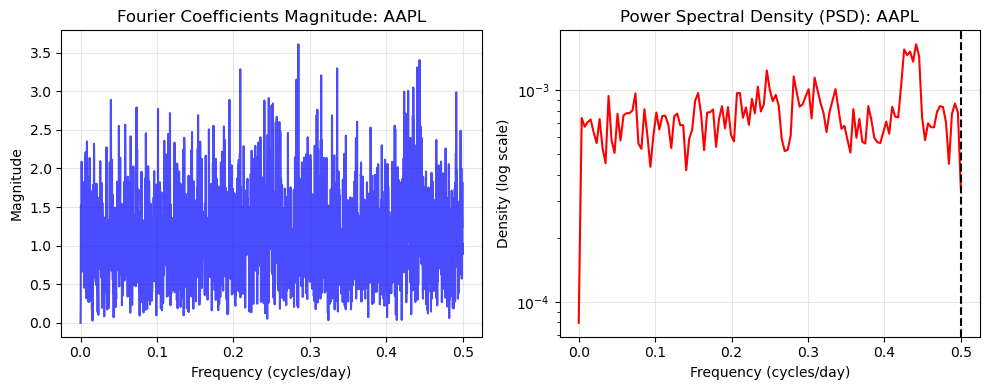

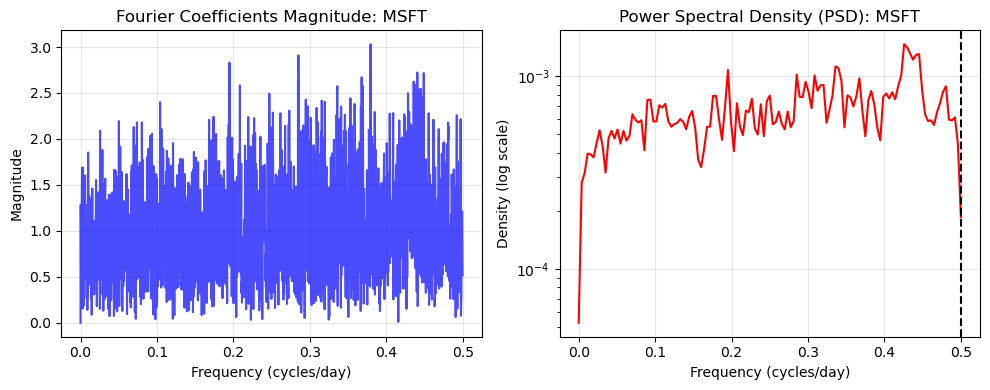

In [38]:
from scipy import signal

def plot_spectral_analysis(X, ticker_name):
    # This solves 'Too many indexers' and 'Key of type tuple' errors
    X_raw = np.asarray(X).flatten()
    
    # 1. Compute Fourier Transform
    n = len(X_raw)
    fft_coeffs = np.fft.fft(X_raw)
    magnitude = np.abs(fft_coeffs)[:n//2]
    freqs = np.fft.fftfreq(n, d=1)[:n//2]

    # 2. Compute Power Spectral Density (PSD)
    f_welch, psd_welch = signal.welch(X_raw, fs=1.0, window='hann', nperseg=256)

    # Plotting
    plt.figure(figsize=(10, 4))

    # Left plot: Fourier Coefficients
    plt.subplot(1, 2, 1)
    plt.plot(freqs, magnitude, color='blue', alpha=0.7)
    plt.title(f'Fourier Coefficients Magnitude: {ticker_name}')
    plt.xlabel('Frequency (cycles/day)')
    plt.ylabel('Magnitude')
    plt.grid(True, alpha=0.3)

    # Right plot: Power Spectral Density
    plt.subplot(1, 2, 2)
    plt.semilogy(f_welch, psd_welch, color='red') 
    plt.title(f'Power Spectral Density (PSD): {ticker_name}')
    plt.xlabel('Frequency (cycles/day)')
    plt.ylabel('Density (log scale)')
    plt.axvline(x=0.5, color='black', linestyle='--', label='Nyquist Freq')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'11_Fourier_and_Power_Spectral_analysis_{ticker_name}.png', format='png', bbox_inches='tight')
    plt.show()

# Now call it directly with your variables
plot_spectral_analysis(X1_centered, tickers[0])
plot_spectral_analysis(X2_centered, tickers[1])

From White Noise Characteristics: The power spectral density (PSD) curves for both AAPL and MSFT are largely flat across the entire frequency range. This indicates that the return series are approximately White Noise, with power distributed almost equally across all frequencies. This is consistent with the efficient market hypothesis (EMH), suggesting returns are not predictable based on past frequencies.

From Periodicity:there are no sharp, dominant peaks in either the Magnitude or PSD plots. Therefore, we can comment that the returns do not exhibit any strong, fixed periodicities (like a strong weekly or monthly cycle).

The flat PSD confirms the previous findings of a Hurst exponent close to 0.5, representing a memoryless random process.

## 6. Empirical Mode Decomposition 

AAPL decomposed into 10 IMFs.
MSFT decomposed into 11 IMFs.


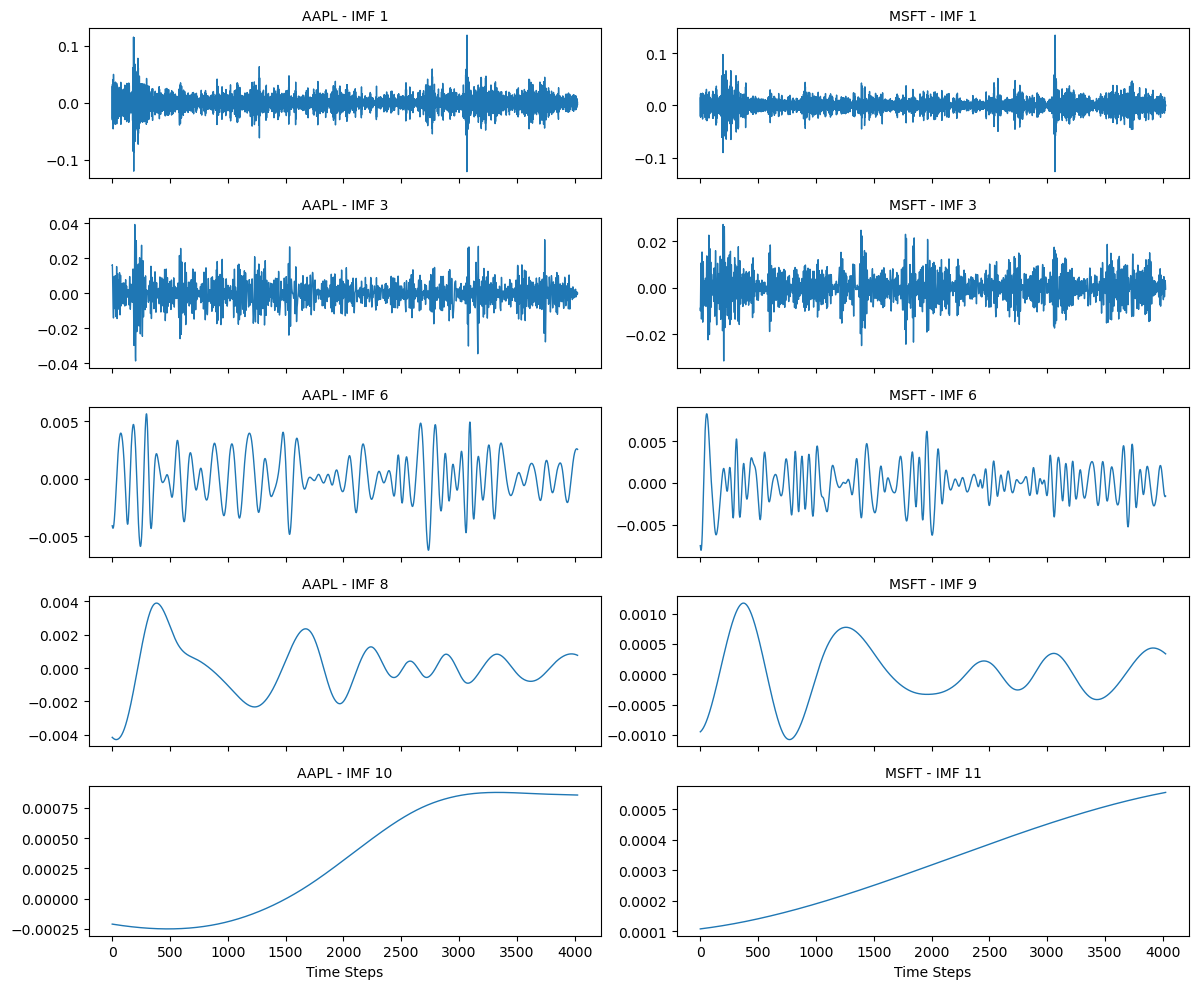

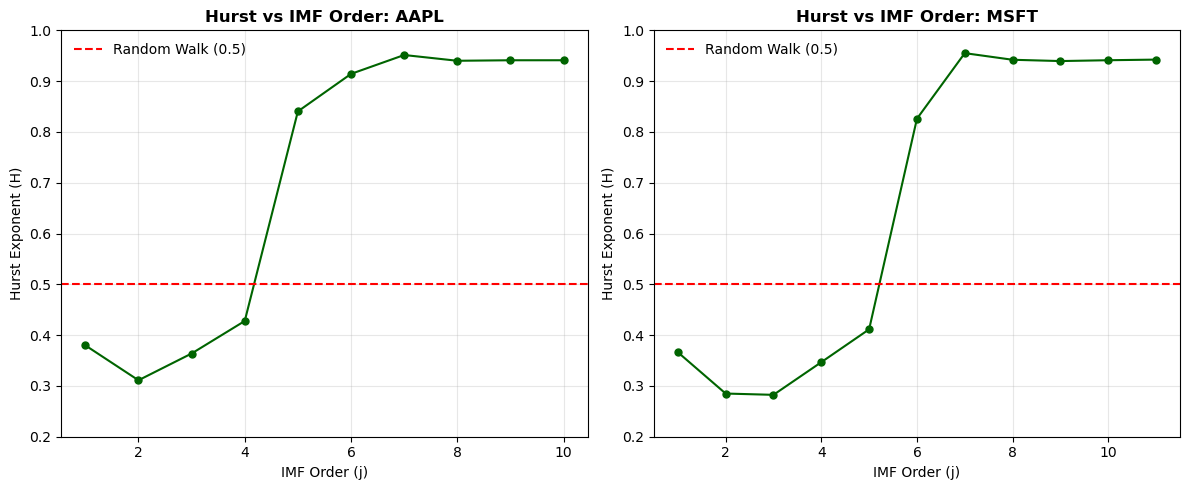

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD
import nolds

def analyze_emd_hurst_combined(series1, series2, tickers):
    data_list = [series1, series2]
    all_imfs = []
    all_hurst = []

    # 1. 计算 EMD 和各阶 IMF 的 Hurst 指数
    for i in range(2):
        X_arr = np.asarray(data_list[i]).flatten()
        emd = EMD()
        imfs = emd(X_arr)
        all_imfs.append(imfs)
        
        h_vals = [nolds.hurst_rs(imf) for imf in imfs]
        all_hurst.append(h_vals)
        print(f"{tickers[i]} decomposed into {len(imfs)} IMFs.")

    # 2. 拼图一：Selected IMFs 对比 (AAPL vs MSFT)
    # 选取代表性阶数：c1, ck/4, ck/2, c3k/4, ck
    fig1, axes1 = plt.subplots(5, 2, figsize=(12, 10), sharex='col')
    for col in range(2):
        imfs = all_imfs[col]
        k = len(imfs)
        indices = [0, k//4, k//2, int(3*k/4), k-1]
        for row, idx in enumerate(indices):
            axes1[row, col].plot(imfs[idx], lw=1)
            axes1[row, col].set_title(f'{tickers[col]} - IMF {idx+1}', fontsize=10)
            if row == 4: axes1[row, col].set_xlabel('Time Steps')
            
    fig1.tight_layout()
    fig1.savefig('emd_imfs_comparison.pdf', format='pdf')
    plt.show()

    # 3. 拼图二：Hurst Exponent vs IMF Order 对比
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    for i, ax in enumerate(axes2):
        h_vals = all_hurst[i]
        k = len(h_vals)
        ax.plot(range(1, k+1), h_vals, 'o-', color='darkgreen', markersize=5)
        ax.axhline(y=0.5, color='r', linestyle='--', label='Random Walk (0.5)')
        
        ax.set_title(f'Hurst vs IMF Order: {tickers[i]}', fontsize=12, fontweight='bold')
        ax.set_xlabel('IMF Order (j)')
        ax.set_ylabel('Hurst Exponent (H)')
        ax.set_ylim(0.2, 1.0) # 统一纵坐标刻度方便对比
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left', frameon=False)

    plt.tight_layout()
    plt.savefig('emd_hurst_comparison.pdf', format='pdf')
    plt.show()

# 执行
analyze_emd_hurst_combined(X1_centered, X2_centered, tickers)

The trend shows a clear transition from anti-persistent (H < 0.5) behavior in lower-order IMFs to highly persistent (H > 0.9) behavior in higher-order IMFs.

1. Lower Orders (j=1 to 4): These components represent high-frequency market noise and volatility, showing a mean-reverting nature.

2. Transition: There is a sharp increase in the Hurst exponent around j=5, representing the filter shifting from noise to structural signals.

3. Higher Orders (j > 6): The Hurst exponent stabilizes near 0.95, indicating that the long-term underlying trends of both AAPL and MSFT are extremely smooth and possess strong positive auto-correlation (long memory).

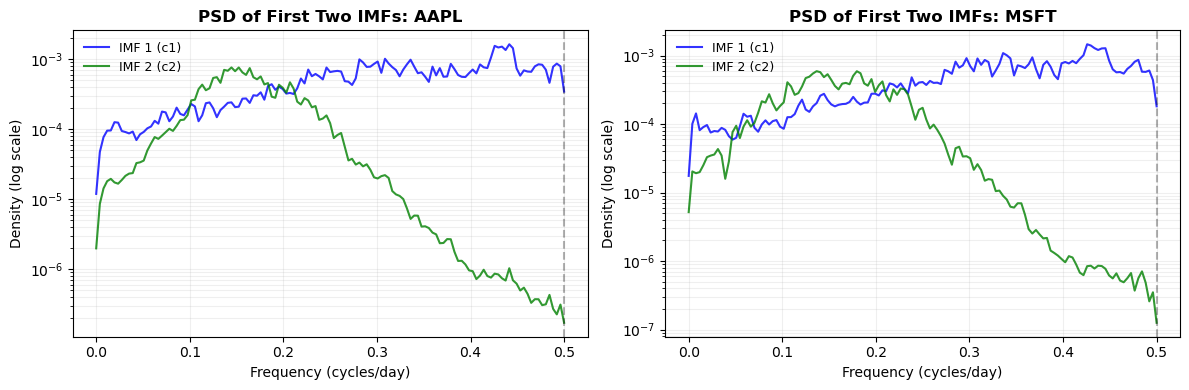

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from PyEMD import EMD

def plot_imf_psd_combined(series1, series2, tickers):
    # Setup the figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    data_list = [series1, series2]
    
    for i, ax in enumerate(axes):
        # 1. Re-run EMD to get IMFs
        X_arr = np.asarray(data_list[i]).flatten()
        emd = EMD()
        imfs = emd(X_arr)
        ticker_name = tickers[i]
        
        # 2. Extract first two IMFs
        c1 = imfs[0]
        c2 = imfs[1]
        
        # 3. Compute PSD for each using Welch's method
        # Using fs=1.0 as per daily frequency
        f1, psd1 = signal.welch(c1, fs=1.0, nperseg=256)
        f2, psd2 = signal.welch(c2, fs=1.0, nperseg=256)
        
        # 4. Plotting on the respective subplot (Log scale)
        ax.semilogy(f1, psd1, label='IMF 1 (c1)', color='blue', alpha=0.8)
        ax.semilogy(f2, psd2, label='IMF 2 (c2)', color='green', alpha=0.8)
        
        ax.set_title(f'PSD of First Two IMFs: {ticker_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Frequency (cycles/day)', fontsize=10)
        ax.set_ylabel('Density (log scale)', fontsize=10)
        ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.3)
        ax.legend(loc='upper left', frameon=False, fontsize=9)
        ax.grid(True, which="both", ls="-", alpha=0.2)

    plt.tight_layout()
    # Exporting as PDF for high-quality LaTeX insertion
    plt.savefig('imf_psd_comparison_combined.png', format='png', bbox_inches='tight')
    plt.show()

# Execution
plot_imf_psd_combined(X1_centered, X2_centered, tickers)

The PSD plots of the first two IMFs exhibit the characteristics of adaptive band-pass filters.
- IMF 1 ($c_1$) acts as a high-frequency extractor, with its power concentrated in the 0.25 - 0.5 cycles/day range, capturing the most rapid oscillations (noise) in the stock returns.
- IMF 2 ($c_2$) shows a peak shifted to the left (lower frequency), primarily covering the 0.1 - 0.2 cycles/day band.

Visually, they look like a dyadic filter bank where each successive IMF captures a lower frequency scale than the previous one. This confirms that EMD effectively decomposes the 'flat' white-noise spectrum of the original returns into distinct, frequency-ordered components.


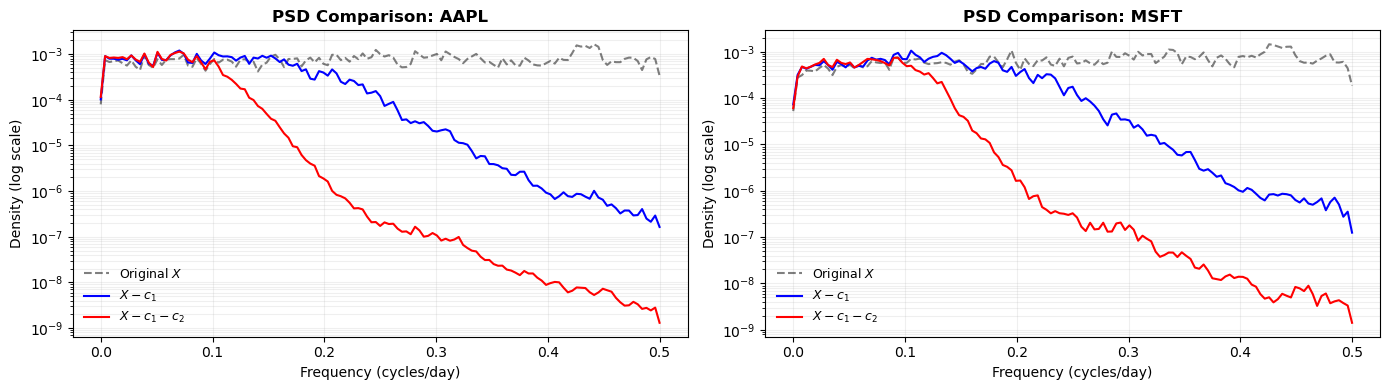

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from PyEMD import EMD

def plot_reduced_psd_combined(series1, series2, tickers):
    # Setup the figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    data_list = [series1, series2]
    
    for i, ax in enumerate(axes):
        # 1. EMD decomposition
        X_raw = np.asarray(data_list[i]).flatten()
        emd = EMD()
        imfs = emd(X_raw)
        ticker_name = tickers[i]
        
        # 2. Define reduced series
        # X - c1 (removes highest frequency)
        X_minus_c1 = X_raw - imfs[0]
        # X - c1 - c2 (removes two highest frequency bands)
        X_minus_c1_c2 = X_raw - imfs[0] - imfs[1]
        
        # 3. Compute PSDs using Welch's method
        f_orig, psd_orig = signal.welch(X_raw, fs=1.0, nperseg=256)
        f_r1, psd_r1 = signal.welch(X_minus_c1, fs=1.0, nperseg=256)
        f_r2, psd_r2 = signal.welch(X_minus_c1_c2, fs=1.0, nperseg=256)
        
        # 4. Plotting (Log scale)
        ax.semilogy(f_orig, psd_orig, label='Original $X$', color='black', alpha=0.5, linestyle='--')
        ax.semilogy(f_r1, psd_r1, label='$X - c_1$', color='blue')
        ax.semilogy(f_r2, psd_r2, label='$X - c_1 - c_2$', color='red')
        
        # Formatting
        ax.set_title(f'PSD Comparison: {ticker_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Frequency (cycles/day)', fontsize=10)
        ax.set_ylabel('Density (log scale)', fontsize=10)
        ax.grid(True, which="both", ls="-", alpha=0.2)
        ax.legend(loc='lower left', frameon=False, fontsize=9)

    plt.tight_layout()
    # Save as PDF for high-quality LaTeX insertion (Overleaf compatible)
    plt.savefig('reduced_psd_comparison_combined.png', format='png', bbox_inches='tight')
    plt.show()

# Execution
plot_reduced_psd_combined(X1_centered, X2_centered, tickers)

The results clearly demonstrate that removing successive IMFs acts as an adaptive low-pass filter. Unlike traditional Fourier filters with fixed cutoff frequencies, EMD identifies the 'noise' floor based on the data's intrinsic scales. As we subtract $c_1$ and $c_2$, the high-frequency 'shimmer' of the stock market is removed, leaving behind a smoother, lower-frequency signal.

Notably, in the very low-frequency range (close to 0), the PSDs of all three series overlap. This suggests that $c_1$ and $c_2$ contain zero long-term trend information. They are purely stochastic oscillations. Their removal 'purifies' the series, allowing the underlying long-term cycles or trends to become more dominant in the power spectrum.

The sharp slope of the red and blue lines compared to the flat gray line illustrates the boundary between the unpredictable noise (high frequency) and the potentially structural components (low frequency) of the financial time series. This provides a more concise representation than a standard Fourier Transform, as it concentrates the significant energy into fewer, physically meaningful components.